# Every figure in the dissertation

One section per figure. Each loads the **raw result files** and draws from them; nothing reads
a summary, a cached table, or a number typed by hand.

Two conventions hold throughout and are worth knowing before reading any plot:

* **Checkpoint.** Structural distance is reported at the checkpoint selected on training
  mutual information. At 12,000 episodes that rule and the final update disagree by more than
  a factor of three on 8 of 21 seeds, in both directions, so figures that compare them say so.
* **Action selection.** Policies are evaluated by sampling at temperature 1, not argmax. On a
  well-behaved policy the two agree to within 0.0002; a large gap is a symptom of a weak
  policy rather than a measurement choice.

`scripts/figures.py` renders the same figures headlessly for the LaTeX build. Edit the
notebook to explore; port a settled change to the script so the built figure follows.

In [1]:
import pathlib, sys, glob, json, subprocess, os
import numpy as np
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
while not (ROOT / "ma").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%matplotlib inline

LEARNED, MYOPIC, RANDOM, THIRD = "#0072B2", "#D55E00", "#999999", "#009E73"
FLOOR = 1e-5          # a true 0.00000 cannot be drawn on a log axis
plt.rcParams.update({"font.family": "serif", "font.serif": ["DejaVu Serif"], "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .5,
                     "figure.dpi": 130})

def jload(rel):
    p = ROOT / rel
    return json.loads(p.read_text()) if p.exists() else None

print("repo root:", ROOT)

repo root: /Users/brianezinwoke/Workspace/federated-active-causal-discovery-with-marl


## Figure 1 — the sweep

Every swept axis against both baselines, on both metrics. This is the backbone: 18 cells,
three seeds each, and the figure the rest of the chapter refers back to.

The table below is what the figure draws. Read the seed counts: the competence floor removes
different runs at different budgets, so a cell can rest on two seeds.

In [2]:
from scripts.figures import _sweep_rows, WINDOW_FLOOR
rows = _sweep_rows()
print(f"{len(rows)} runs, {len({(r['k'],r['sigma'],r['n'],r['beta']) for r in rows})} cells")
excl = [r for r in rows if r["wr"] < WINDOW_FLOOR]
print(f"below the competence floor: {len(excl)} -> seeds {sorted(r['seed'] for r in excl)}")

60 runs, 20 cells
below the competence floor: 0 -> seeds []


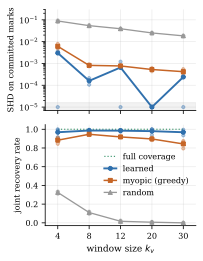

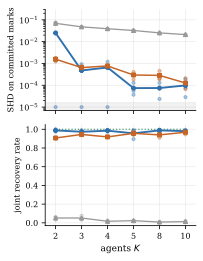

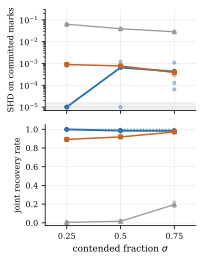

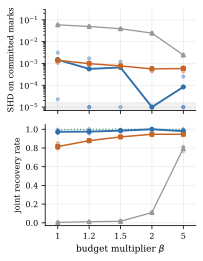

In [3]:
from scripts.figures import fig_sweep_grid
out = ROOT / "thesis/figures"
fig_sweep_grid(out)
from IPython.display import Image
# Split into four print-true panels on 3 Sep (FIGURE_GUIDELINES.md): a=window,
# b=federation size, c=contention, d=budget.
from IPython.display import display
for tag in 'abcd':
    os.system(f'sips -s format png --out {out}/_tmp_{tag}.png {out}/sweep_grid_{tag}.pdf >/dev/null 2>&1')
    display(Image(filename=str(out / f'_tmp_{tag}.png'), width=430))

## Figure 2 — the crossover, at both training budgets

The published claim was a sign change between $k_v=8$ and $k_v=12$. Drawn at both budgets it
is visibly a property of the budget: at 12,000 episodes the learned policy wins at every
window size.

Missing cells break the line rather than being interpolated across, and the 4,000-episode
series stops at $k_v=12$ because $k_v=20$ and $k_v=30$ were only ever trained at 12,000.

In [4]:
for k in (4, 8, 12, 20, 30):
    b4 = jload(f"results/ckpt/k{k:02d}_best.json") if k <= 12 else None
    cell = {4: "k04s50n04b150", 8: "k08s50n04b150", 12: "k12s50n04b150"}.get(k)
    b12 = jload(f"results/sweep12k/shd/{cell}.json") if cell else jload(
        f"results/ckpt/k{k:02d}_best.json")
    f = lambda d: np.mean([e["means"]["learned"]["hard"] for e in d]) if d else float("nan")
    g = np.mean([e["means"]["greedy"]["hard"]
                 for e in jload(f"results/ckpt/k{k:02d}_best.json")])
    print(f"  k={k:<3} 4,000 ep {f(b4):9.5f}   12,000 ep {f(b12):9.5f}   myopic {g:9.5f}")

  k=4   4,000 ep   0.01024   12,000 ep   0.00302   myopic   0.00611
  k=8   4,000 ep   0.00113   12,000 ep   0.00016   myopic   0.00082
  k=12  4,000 ep   0.00014   12,000 ep   0.00065   myopic   0.00077
  k=20  4,000 ep       nan   12,000 ep   0.00000   myopic   0.00053
  k=30  4,000 ep       nan   12,000 ep   0.00038   myopic   0.00042


wrote crossover_budget.pdf


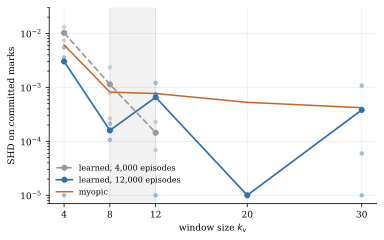

In [5]:
subprocess.run([sys.executable, str(ROOT / "scripts/fig_crossover_budget.py")], cwd=ROOT)
os.system(f'sips -s format png --out {out}/_tmp2.png {out}/crossover_budget.pdf >/dev/null 2>&1')
Image(filename=str(out / "_tmp2.png"), width=620)

## Figure 3 — checkpoint selection

Selected against final against myopic. The two conventions agree below the crossover and
diverge above it, and the divergence goes in **both** directions depending on the cell, which
is why the chapter reports both columns rather than choosing one.

In [6]:
sel = fin = ok = 0
for p in sorted(glob.glob(str(ROOT / "results/sweep12k/shd_final/*.json"))):
    cell = os.path.basename(p)[:-5]
    b = jload(f"results/sweep12k/shd/{cell}.json")
    if not b: continue
    for x, y in zip(b, json.loads(pathlib.Path(p).read_text())):
        B, F = x["means"]["learned"]["hard"], y["means"]["learned"]["hard"]
        r = (max(B, F) + 1e-9) / (min(B, F) + 1e-9)
        ok, sel, fin = (ok + 1, sel, fin) if r <= 3 else (
            (ok, sel + 1, fin) if B > F else (ok, sel, fin + 1))
print(f"seeds measured both ways: {ok+sel+fin}")
print(f"  agree within 3x      {ok}")
print(f"  selected much worse  {sel}")
print(f"  final much worse     {fin}")

seeds measured both ways: 42
  agree within 3x      30
  selected much worse  4
  final much worse     8


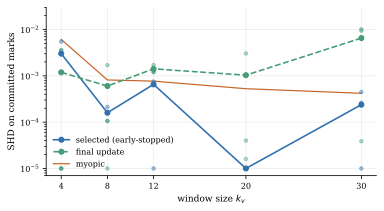

In [7]:
from scripts.figures import fig_checkpoint
fig_checkpoint(out)
os.system(f'sips -s format png --out {out}/_tmp3.png {out}/checkpoint.pdf >/dev/null 2>&1')
Image(filename=str(out / "_tmp3.png"), width=620)

## Figure 4 — the price of federation

Arm A is the federated system; arm E removes the information and optimiser partitions. Action
rights stay partitioned in both, so this is not the cost of decentralisation entire.

The coordination baselines matter more than the A/E comparison: a communication-free positional
convention is **worse** than not coordinating at all.

In [8]:
for cell in ("k12", "k20"):
    A = [jload(p.replace(str(ROOT) + "/", "")) for p in
         sorted(glob.glob(str(ROOT / f"results/central/v2_{cell}_A_s?.json")))]
    E = [jload(p.replace(str(ROOT) + "/", "")) for p in
         sorted(glob.glob(str(ROOT / f"results/central/v2_{cell}_E_s?.json")))]
    g = lambda R, k: np.mean([r["arms"][k]["success"] for r in R if r["arms"].get(k)])
    print(f"  {cell}: random {g(A,'random_vary'):.3f}  fixed-partition "
          f"{g(A,'greedy_partitioned'):.3f}  myopic {g(A,'greedy_uncertainty'):.3f}  "
          f"learned {g(A,'learned'):.3f}  centralised {g(E,'learned'):.3f}")

  k12: random 0.025  fixed-partition 0.745  myopic 0.927  learned 0.971  centralised 0.962
  k20: random 0.007  fixed-partition 0.487  myopic 0.897  learned 0.998  centralised 1.000


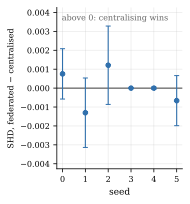

In [9]:
from scripts.figures import fig_federation
fig_federation(out)
os.system(f'sips -s format png --out {out}/_tmp4.png {out}/federation_a.pdf >/dev/null 2>&1')
Image(filename=str(out / "_tmp4.png"), width=800)
# panel (b), the paired six-seed comparison:
os.system(f'sips -s format png --out {out}/_tmpb.png {out}/federation_b.pdf >/dev/null 2>&1')
from IPython.display import display
display(Image(filename=str(out / '_tmpb.png'), width=380))

## Figure 5 — attribution obeys a closed form

`scripts/attr_model.py` is run live rather than transcribed. The one-peer cell is excluded by
the model's own construction and must sit **off** the line; if it ever sits on it, the model is
fitting something it should not.

          cell partners P(res|1pair) share 1pair predicted measured residual
----------------------------------------------------------------------------
     k12s50n02        1        1.000       0.225     0.225    0.488   +0.263
     k12s50n03        2        0.798       0.389     0.310    0.284   -0.026
     k12s50n04        3        0.765       0.477     0.365    0.330   -0.034
     k12s50n08        7        0.047       0.639     0.030    0.028   -0.002
     k12s25n04        3        0.941       0.845     0.795    0.755   -0.041
     k12s75n04        3        0.782       0.335     0.262    0.267   +0.005
     k20s50n04        3        0.667       0.321     0.214    0.196   -0.018

largest absolute residual: 0.263
Groups explaining two or more pairs are assumed to contribute ZERO, which holds at
every partner count above one. At ONE partner they do contribute and the model
under-predicts by design -- that cell is the exception that identifies the cause.



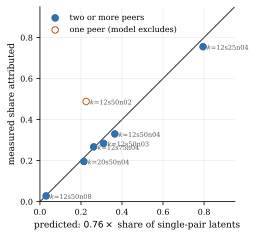

In [10]:
from scripts.figures import fig_attribution_law
print(subprocess.run([sys.executable, str(ROOT / "scripts/attr_model.py")],
                     capture_output=True, text=True, cwd=ROOT).stdout)
fig_attribution_law(out)
os.system(f'sips -s format png --out {out}/_tmp5.png {out}/attribution_law.pdf >/dev/null 2>&1')
Image(filename=str(out / "_tmp5.png"), width=440)

## Figure 6 — the answer-rate curve

Transfer against the answer rate, from `results/power/rho/`. Produced on the second machine;
the raw files are in `submission/transfer/`.

### Figure 6 is not yet a figure

The cell below prints `results/power/rho/CURVE.json` rather than plotting it, and that file
holds the **pre-fix** answer-rate grid: it was measured before the evaluation RNG was seeded
(2 Sep 21:15) and does not reproduce. Agent B is rebuilding the full 21-cell grid into
`results/power/rho/deterministic/`. When it lands, point this cell at the new directory and
draw the curve. Until then the numbers below are shown as raw data so that nobody mistakes a
plot for a settled result.


In [11]:
curve = jload("results/power/rho/CURVE.json")
if curve is None:
    print("CURVE.json not present -- pull from the second machine before running this cell")
else:
    print(json.dumps(curve, indent=1)[:1200])

{
 "curve": [
  {
   "rho": 1.0,
   "n_seeds": 3,
   "mean_learned_hard": 0.059361702127659566,
   "mean_greedy_hard": 0.04845744680851064,
   "mean_delta": 0.010904255319148938,
   "seed_se": 0.00727907603616314,
   "per_seed_delta": [
    0.010691489361702129,
    -0.0015957446808510644,
    0.023617021276595748
   ],
   "verdict": "tied"
  },
  {
   "rho": 0.95,
   "n_seeds": 3,
   "mean_learned_hard": 0.05040780141843971,
   "mean_greedy_hard": 0.04845744680851064,
   "mean_delta": 0.001950354609929078,
   "seed_se": 0.0012223759683080272,
   "per_seed_delta": [
    0.004202127659574468,
    3.469446951953614e-20,
    0.0016489361702127663
   ],
   "verdict": "tied"
  },
  {
   "rho": 0.9,
   "n_seeds": 3,
   "mean_learned_hard": 0.0401950354609929,
   "mean_greedy_hard": 0.04845744680851064,
   "mean_delta": -0.008262411347517729,
   "seed_se": 0.00041920533395520883,
   "per_seed_delta": [
    -0.008138297872340425,
    -0.007606382978723404,
    -0.009042553191489361
   ],
   "v

## Housekeeping

Remove the temporary PNGs used for inline display; the PDFs are what LaTeX includes.

In [12]:
for f in glob.glob(str(out / "_tmp*.png")):
    os.remove(f)
print("cleaned")

cleaned
